In [8]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag
import json

In [9]:
com_port1="/dev/tty.usbmodem21201"
tag1=Tag(com_port1)
print(tag1.get_mac())

com_port2="/dev/tty.usbmodem213301"
tag2=Tag(com_port2)
print(tag2.get_mac())


b'{"mac":"98:A3:16:8F:58:E8"}\n'
b'{"mac":"58:E6:C5:01:08:CC"}\n'


In [10]:
tag1.listen_esync()
tag2.listen_esync()

b'esync:listening\r\n' 	 b'esync:listening\r\n'
b'esync:listening\r\n' 	 b'esync:listening\r\n'


In [11]:
tag1.queue_adc_read(300)
tag2.queue_mpp(1)

b'q:queued, adc_300\n' 	 b'q:queued, adc_300\n'
b'q:queued, mpp_1\n' 	 b'q:queued, mpp_1\n'


In [12]:
print(tag2.read_queued(10))
print("----")
print(tag2.read_queued(10))



{'info': 'esync', 'edge': 'rise', 't_us': 145282857, 'low_us': 197684, 'min_mv': 0.381, 'base_mv': 117.266}
----
{'info': 'mpp', 'ch': 8, 'passes': 1, 'ok': 1}


In [13]:
print(tag1.read_queued(10))
print("----")
mpp_data=tag1.read_queued(10)



{'info': 'esync', 'edge': 'rise', 't_us': 103444598, 'low_us': 197841, 'min_mv': 0.305, 'base_mv': 95.903}
----


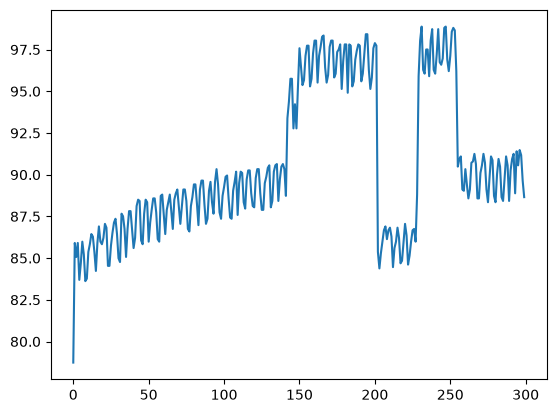

In [14]:
plt.plot(list(map(float, mpp_data['data'].split(','))))
plt.show()